In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import joblib

try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False

try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except ImportError:
    lgbm_available = False

try:
    from catboost import CatBoostClassifier
    catboost_available = True
except ImportError:
    catboost_available = False

In [26]:
# Load dataset
file_path = (r"C:\Users\LENOVO\OneDrive\Desktop\Pro\deepseek_vs_chatgpt.csv")
df = pd.read_csv(file_path)
# Display basic info and first few rows
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           10000 non-null  object 
 1   Month_Num                      10000 non-null  int64  
 2   Weekday                        10000 non-null  object 
 3   AI_Platform                    10000 non-null  object 
 4   AI_Model_Version               10000 non-null  object 
 5   Active_Users                   10000 non-null  int64  
 6   New_Users                      10000 non-null  int64  
 7   Churned_Users                  10000 non-null  int64  
 8   Daily_Churn_Rate               10000 non-null  float64
 9   Retention_Rate                 10000 non-null  float64
 10  User_ID                        10000 non-null  object 
 11  Query_Type                     10000 non-null  object 
 12  Input_Text                     10000 non-null  

,Date,Month_Num,Weekday,AI_Platform,AI_Model_Version,Active_Users,New_Users,Churned_Users,Daily_Churn_Rate,Retention_Rate,...,Session_Duration_sec,Device_Type,Language,Response_Accuracy,Response_Speed_sec,Response_Time_Category,Correction_Needed,User_Return_Frequency,Customer_Support_Interactions,Region
0,2024-09-21,9,Saturday,ChatGPT,GPT-4-turbo,500000,25000,25000,0.05,0.95,...,40,Mobile,es,0.7842,3.30,Standard,0,6,2,Antarctica (the territory South of 60 deg S)
1,2024-09-21,9,Saturday,ChatGPT,GPT-4-turbo,500000,25000,25000,0.05,0.95,...,24,Laptop/Desktop,zh,0.8194,3.28,Standard,1,2,2,Ukraine
2,2024-09-21,9,Saturday,ChatGPT,GPT-4-turbo,500000,25000,25000,0.05,0.95,...,34,Mobile,en,0.8090,3.07,Standard,0,2,0,Grenada
3,2024-09-21,9,Saturday,ChatGPT,GPT-4-turbo,500000,25000,25000,0.05,0.95,...,18,Mobile,fr,0.8233,3.06,Standard,0,9,0,Guyana
4,2024-05-16,5,Thursday,DeepSeek,DeepSeek-Chat 1.5,1700000,170000,34000,0.02,0.95,...,10,Mobile,de,0.9366,1.48,Fast,0,9,3,India


In [3]:
# Data Cleaning
df['Response_Accuracy'] = pd.to_numeric(df['Response_Accuracy'], errors='coerce')
df['Response_Accuracy'].fillna(df['Response_Accuracy'].mean(), inplace=True)
df.drop_duplicates(inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18116\3492501761.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Response_Accuracy'].fillna(df['Response_Accuracy'].mean(), inplace=True)


In [4]:
# Encode categorical features
encoder = LabelEncoder()
df['AI_Platform'] = encoder.fit_transform(df['AI_Platform'])
df['Query_Type'] = encoder.fit_transform(df['Query_Type'])

In [5]:
# Feature Selection
features = ['AI_Platform', 'Query_Type', 'Response_Tokens', 'User_Experience_Score',
            'Response_Speed_sec', 'Correction_Needed']
X = df[features]
y = df['Response_Accuracy'] > df['Response_Accuracy'].mean()  # Binary target based on average accuracy

In [6]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Standardize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
# Define base models
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(),
    'SVM': SVC(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'HistGradientBoosting': HistGradientBoostingClassifier()
}

if xgb_available:
    models['XGBoost'] = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
if lgbm_available:
    models['LightGBM'] = LGBMClassifier()
if catboost_available:
    models['CatBoost'] = CatBoostClassifier(verbose=0)

In [29]:
# Hyperparameter tuning
best_estimators = {}
for name, model in models.items():
    print(f"\nRunning GridSearchCV for {name}...")
    if name == 'Random Forest':
        param_grid = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]}
    elif name == 'Logistic Regression':
        param_grid = {'C': [0.01, 0.1, 1, 10]}
    elif name == 'SVM':
        param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
    elif name == 'Gradient Boosting' or name == 'HistGradientBoosting':
        param_grid = {'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7]}
    elif name == 'XGBoost':
        param_grid = {'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7]}
    elif name == 'LightGBM':
        param_grid = {'learning_rate': [0.01, 0.1], 'num_leaves': [31, 50]}
    elif name == 'CatBoost':
        param_grid = {'depth': [4, 6, 8], 'learning_rate': [0.01, 0.1]}
    else:
        param_grid = {}

    grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_estimators[name] = grid.best_estimator_
    print(f"Best Params for {name}: {grid.best_params_}")


Running GridSearchCV for Random Forest...
Best Params for Random Forest: {'max_depth': 10, 'n_estimators': 200}

Running GridSearchCV for Logistic Regression...
Best Params for Logistic Regression: {'C': 0.01}

Running GridSearchCV for SVM...
Best Params for SVM: {'C': 0.1, 'kernel': 'linear'}

Running GridSearchCV for Gradient Boosting...
Best Params for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 3}

Running GridSearchCV for HistGradientBoosting...
Best Params for HistGradientBoosting: {'learning_rate': 0.1, 'max_depth': 7}


In [30]:
# Metrics storage
accuracies = {}
precisions = {}
recalls = {}
f1_scores = {}
best_model = None
best_accuracy = 0

for name, model in best_estimators.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    accuracies[name] = acc
    precisions[name] = pre
    recalls[name] = rec
    f1_scores[name] = f1

    print(f"{name} Accuracy: {acc:.4f}")
    print(f"Precision: {pre:.4f}, Recall: {rec:.4f}, F1-Score: {f1:.4f}\n")

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = name
        joblib.dump(model, "best_model.pkl")

print(f"Best Model: {best_model} with Accuracy: {best_accuracy:.4f} (Saved as best_model.pkl)")

Random Forest Accuracy: 0.7850
Precision: 0.8920, Recall: 0.7273, F1-Score: 0.8013

Logistic Regression Accuracy: 0.7835
Precision: 0.8925, Recall: 0.7240, F1-Score: 0.7994

SVM Accuracy: 0.7835
Precision: 0.8925, Recall: 0.7240, F1-Score: 0.7994

Gradient Boosting Accuracy: 0.7845
Precision: 0.8903, Recall: 0.7282, F1-Score: 0.8011

HistGradientBoosting Accuracy: 0.7975
Precision: 0.8702, Recall: 0.7760, F1-Score: 0.8204

Best Model: HistGradientBoosting with Accuracy: 0.7975 (Saved as best_model.pkl)


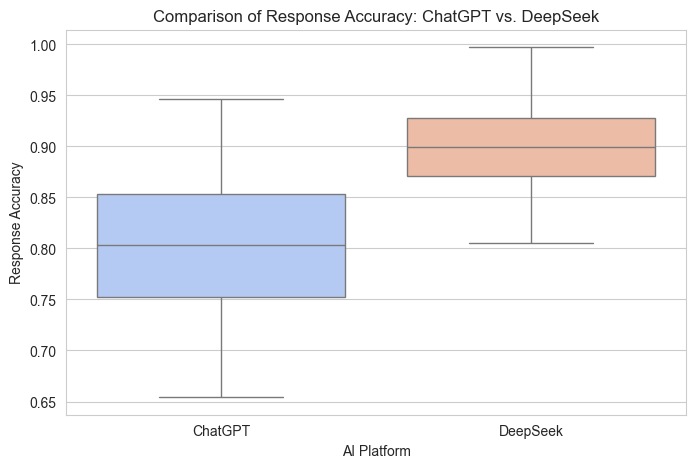

In [31]:
# --- Visualization Section (Preserved) ---
sns.set_style("whitegrid")

# Accuracy by Platform
plt.figure(figsize=(8, 5))
sns.boxplot(x="AI_Platform", y="Response_Accuracy", hue="AI_Platform", data=df, palette="coolwarm", legend=False)
plt.title("Comparison of Response Accuracy: ChatGPT vs. DeepSeek")
plt.xlabel("AI Platform")
plt.ylabel("Response Accuracy")
plt.show()

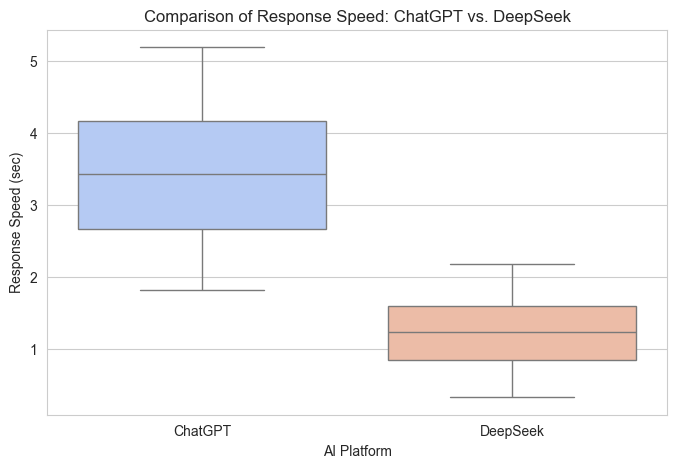

In [32]:
# Speed by Platform
plt.figure(figsize=(8, 5))
sns.boxplot(x="AI_Platform", y="Response_Speed_sec", hue="AI_Platform", data=df, palette="coolwarm", legend=False)
plt.title("Comparison of Response Speed: ChatGPT vs. DeepSeek")
plt.xlabel("AI Platform")
plt.ylabel("Response Speed (sec)")
plt.show()

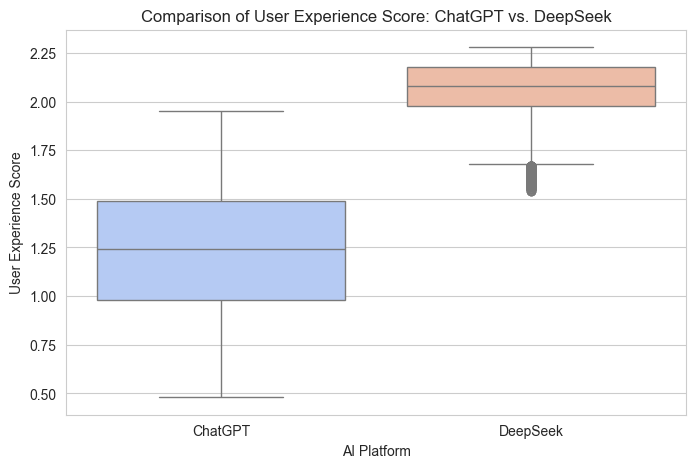

In [33]:
# UX Score by Platform
plt.figure(figsize=(8, 5))
sns.boxplot(x="AI_Platform", y="User_Experience_Score", hue="AI_Platform", data=df, palette="coolwarm", legend=False)
plt.title("Comparison of User Experience Score: ChatGPT vs. DeepSeek")
plt.xlabel("AI Platform")
plt.ylabel("User Experience Score")
plt.show()

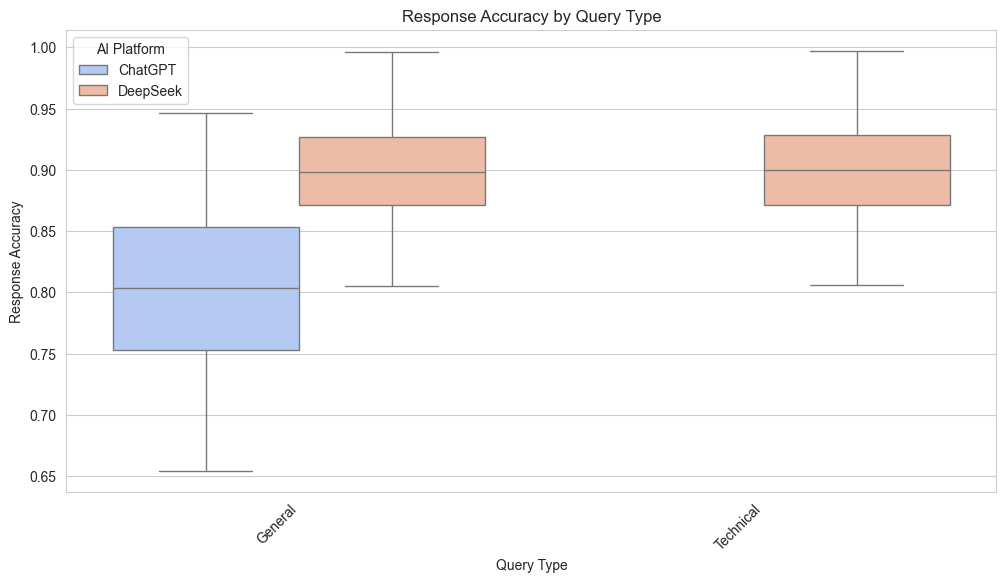

In [34]:
# Accuracy by Query Type
plt.figure(figsize=(12, 6))
sns.boxplot(x="Query_Type", y="Response_Accuracy", hue="AI_Platform", data=df, palette="coolwarm")
plt.xticks(rotation=45, ha="right")
plt.title("Response Accuracy by Query Type")
plt.xlabel("Query Type")
plt.ylabel("Response Accuracy")
plt.legend(title="AI Platform")
plt.show()

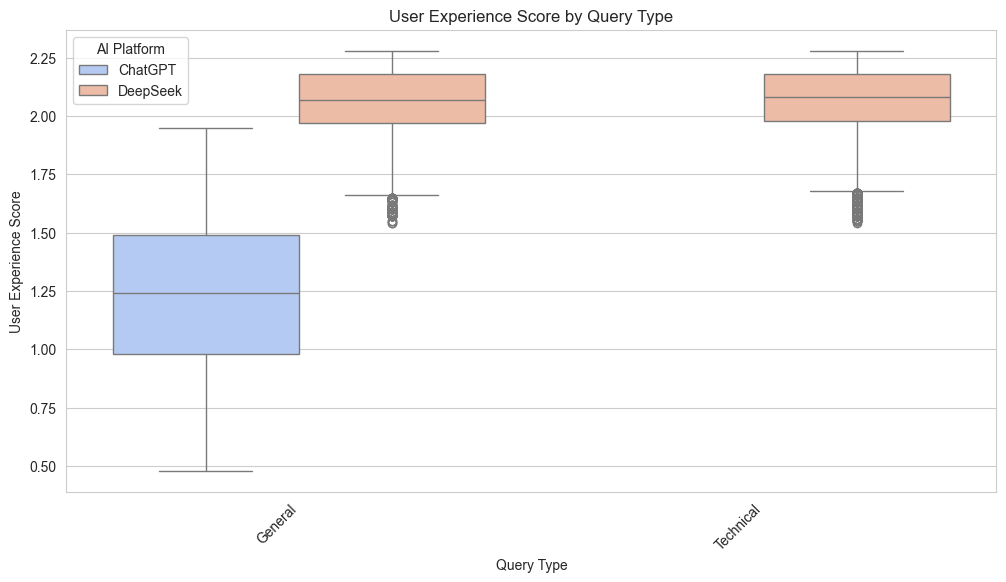

In [35]:
# UX Score by Query Type
plt.figure(figsize=(12, 6))
sns.boxplot(x="Query_Type", y="User_Experience_Score", hue="AI_Platform", data=df, palette="coolwarm")
plt.xticks(rotation=45, ha="right")
plt.title("User Experience Score by Query Type")
plt.xlabel("Query Type")
plt.ylabel("User Experience Score")
plt.legend(title="AI Platform")
plt.show()

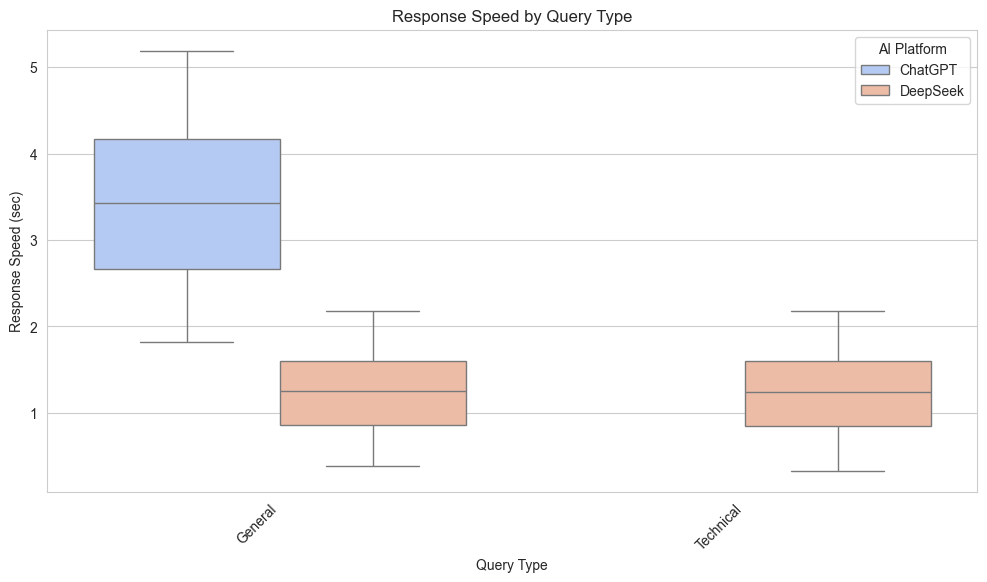

In [36]:
# Speed by Query Type
plt.figure(figsize=(12, 6))
sns.boxplot(x="Query_Type", y="Response_Speed_sec", hue="AI_Platform", data=df, palette="coolwarm")
plt.xticks(rotation=45, ha="right")
plt.title("Response Speed by Query Type")
plt.xlabel("Query Type")
plt.ylabel("Response Speed (sec)")
plt.legend(title="AI Platform")
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18116\2937090629.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette="viridis")


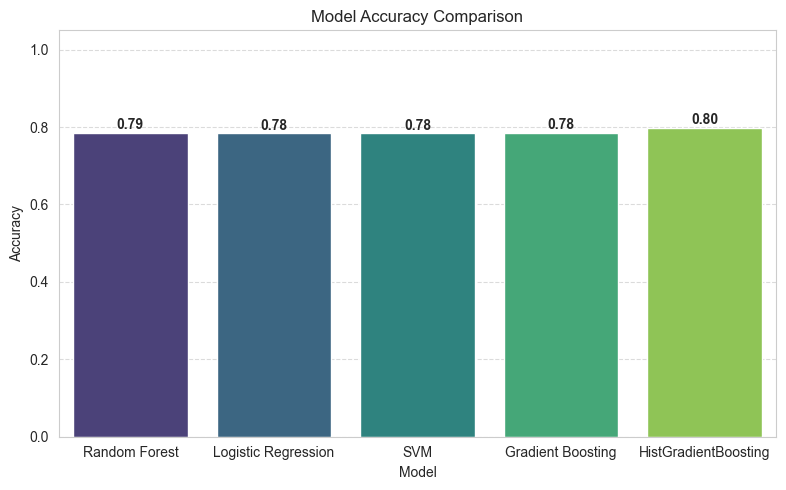

In [37]:
# --- Model Accuracy Comparison Bar Chart ---
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette="viridis")
for i, v in enumerate(accuracies.values()):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18116\1172488524.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), palette="mako")


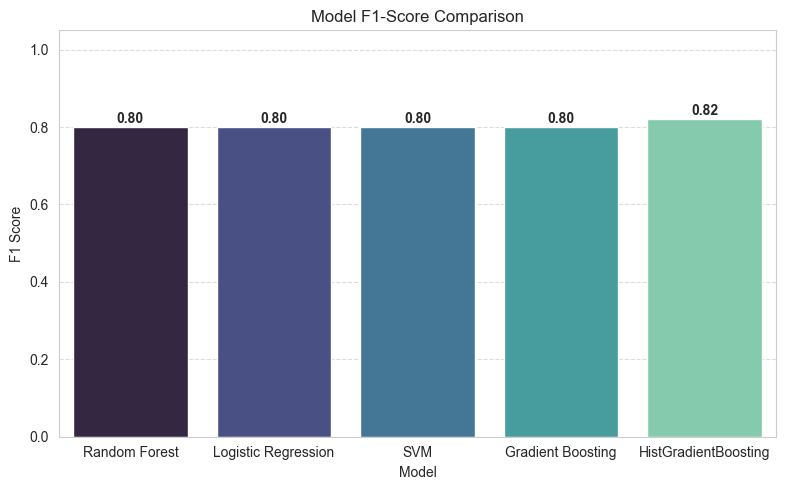

In [38]:
# --- F1 Score Comparison Bar Chart ---
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), palette="mako")
for i, v in enumerate(f1_scores.values()):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
plt.title("Model F1-Score Comparison")
plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18116\2584064012.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(precisions.keys()), y=list(precisions.values()), palette="crest")


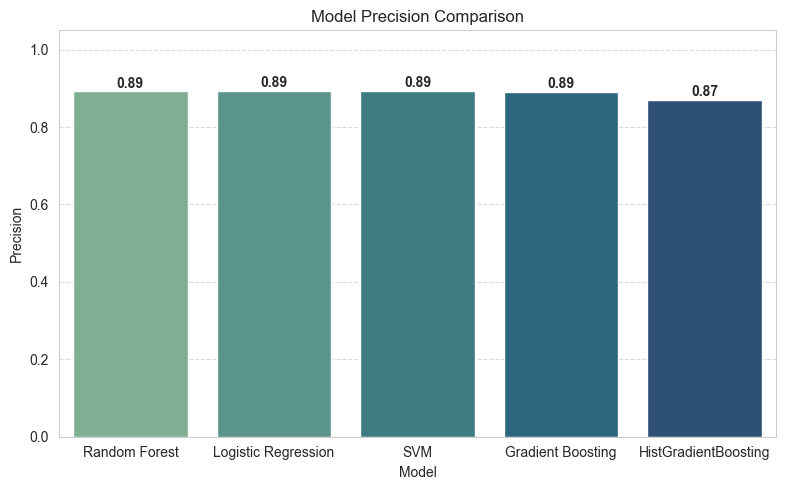

In [39]:
# --- Precision Comparison ---
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=list(precisions.keys()), y=list(precisions.values()), palette="crest")
for i, v in enumerate(precisions.values()):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
plt.title("Model Precision Comparison")
plt.ylabel("Precision")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18116\2704601256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(recalls.keys()), y=list(recalls.values()), palette="rocket")


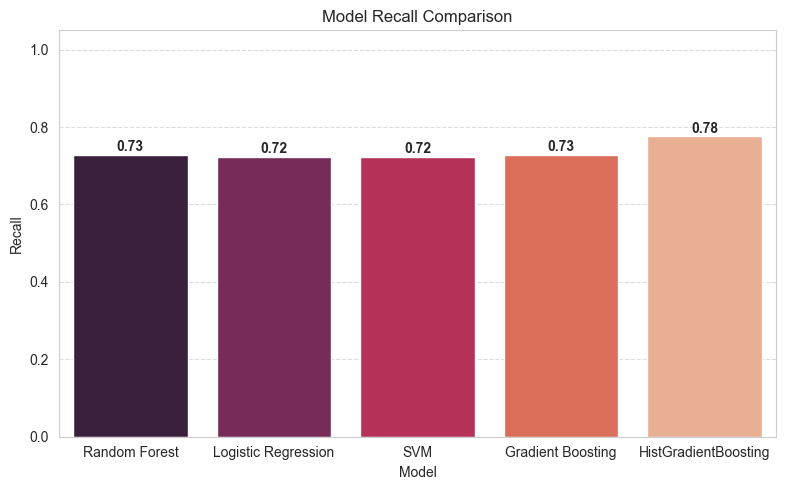

In [40]:
# --- Recall Comparison ---
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=list(recalls.keys()), y=list(recalls.values()), palette="rocket")
for i, v in enumerate(recalls.values()):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
plt.title("Model Recall Comparison")
plt.ylabel("Recall")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [41]:
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']